(numpy_numba_jax)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# NumPy در مقابل Numba در مقابل JAX

در سخنرانی‌های قبلی، سه کتابخانه اصلی برای محاسبات علمی و عددی را بحث کردیم:

* [NumPy](numpy)
* [Numba](numba)
* [JAX](jax_intro)

کدام یک را باید در هر موقعیت استفاده کنیم؟

این سخنرانی به آن سؤال پاسخ می‌دهد، حداقل تا حدی، با بحث در مورد برخی موارد استفاده.

قبل از شروع، توجه می‌کنیم که دو مورد اول یک جفت طبیعی هستند: NumPy و Numba به خوبی با هم کار می‌کنند.

JAX، از سوی دیگر، به تنهایی می‌ایستد.

هنگام بررسی هر رویکرد، نه تنها کارایی و رد پای حافظه، بلکه وضوح و سهولت استفاده را نیز در نظر خواهیم گرفت.

علاوه بر آنچه در Anaconda موجود است، این سخنرانی به کتابخانه‌های زیر نیاز دارد:

In [1]:
!pip install quantecon jax

```{include} _admonition/gpu.md
```

ما از import های زیر استفاده خواهیم کرد.

In [2]:
import random
from functools import partial

import numpy as np
import numba
import quantecon as qe
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm
import jax
import jax.numpy as jnp
from jax import lax

## عملیات برداری شده

برخی عملیات را می‌توان به طور کامل برداری کرد --- تمام حلقه‌ها به راحتی حذف می‌شوند و عملیات عددی به محاسبات روی آرایه‌ها تقلیل می‌یابند.

در این حالت، کدام رویکرد بهترین است؟

### بیان مسئله

مسئله بیشینه‌سازی تابع $f$ از دو متغیر $(x,y)$ روی مربع $[-a, a] \times [-a, a]$ را در نظر بگیرید.

برای $f$ و $a$ بیایید انتخاب کنیم

$$
f(x,y) = \frac{\cos(x^2 + y^2)}{1 + x^2 + y^2}
\quad \text{و} \quad
a = 3
$$

در اینجا نمودار $f$ آمده است

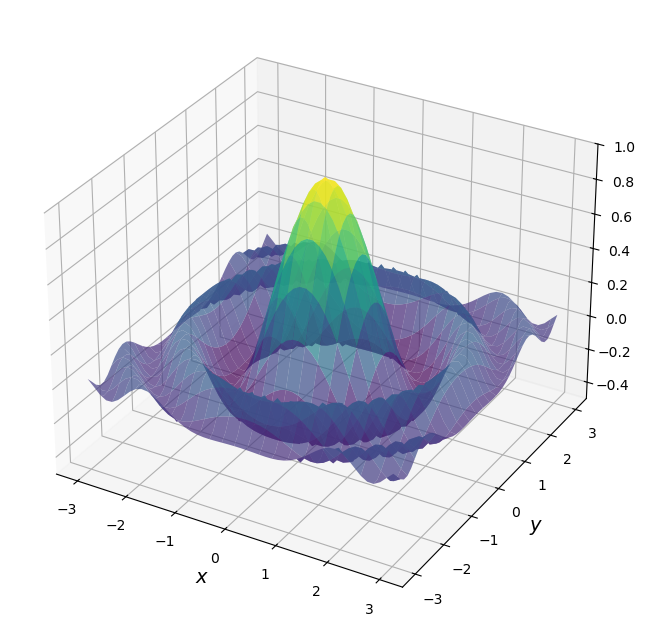

In [3]:
def f(x, y):
    return np.cos(x**2 + y**2) / (1 + x**2 + y**2)

xgrid = np.linspace(-3, 3, 50)
ygrid = xgrid
x, y = np.meshgrid(xgrid, ygrid)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x,
                y,
                f(x, y),
                rstride=2, cstride=2,
                cmap=cm.viridis,
                alpha=0.7,
                linewidth=0.25)
ax.set_zlim(-0.5, 1.0)
ax.set_xlabel('$x$', fontsize=14)
ax.set_ylabel('$y$', fontsize=14)
plt.show()

به خاطر این تمرین، ما از روش brute force برای بیشینه‌سازی استفاده خواهیم کرد.

1. $f$ را برای تمام $(x,y)$ در یک شبکه روی مربع ارزیابی کنید.
1. حداکثر مقادیر مشاهده شده را برگردانید.

فقط برای نشان دادن ایده، در اینجا یک نسخه غیر برداری شده است که از حلقه‌های Python استفاده می‌کند.

In [4]:
grid = np.linspace(-3, 3, 50)
m = -np.inf
for x in grid:
    for y in grid:
        z = f(x, y)
        if z > m:
            m = z

### برداری‌سازی NumPy

اگر به برداری‌سازی به سبک NumPy تغییر دهیم، می‌توانیم از یک شبکه بسیار بزرگتر استفاده کنیم و کد نسبتاً سریع اجرا می‌شود.

در اینجا از `np.meshgrid` برای ایجاد شبکه‌های ورودی دوبعدی `x` و `y` استفاده می‌کنیم به گونه‌ای که `f(x, y)` تمام ارزیابی‌ها را روی شبکه حاصلضرب تولید می‌کند.

(این استراتژی به Matlab بازمی‌گردد.)

In [5]:
grid = np.linspace(-3, 3, 3_000)
x, y = np.meshgrid(grid, grid)

with qe.Timer():
    z_max_numpy = np.max(f(x, y))

print(f"NumPy result: {z_max_numpy:.6f}")

0.1665 seconds elapsed
NumPy result: 0.999998


در نسخه برداری شده، تمام حلقه‌ها در کد کامپایل شده انجام می‌شوند.

علاوه بر این، NumPy از چندنخی ضمنی استفاده می‌کند، به طوری که حداقل مقداری موازی‌سازی رخ می‌دهد.

(موازی‌سازی نمی‌تواند بسیار کارآمد باشد زیرا فایل باینری قبل از اینکه اندازه آرایه‌های `x` و `y` را ببیند کامپایل می‌شود.)

### مقایسه با Numba

حالا بیایید ببینیم آیا می‌توانیم با استفاده از Numba با یک حلقه ساده به عملکرد بهتری دست یابیم.

In [6]:
@numba.jit
def compute_max_numba(grid):
    m = -np.inf
    for x in grid:
        for y in grid:
            z = np.cos(x**2 + y**2) / (1 + x**2 + y**2)
            m = max(m, z)
    return m

بیایید آن را آزمایش کنیم:

In [7]:
grid = np.linspace(-3, 3, 3_000)

with qe.Timer():
    # First run
    z_max_numba = compute_max_numba(grid)

print(f"Numba result: {z_max_numba:.6f}")

0.2352 seconds elapsed
Numba result: 0.999998


بیایید دوباره اجرا کنیم تا زمان کامپایل حذف شود.

In [8]:
with qe.Timer():
    # Second run
    compute_max_numba(grid)

0.1074 seconds elapsed


بسته به دستگاه شما، نسخه Numba ممکن است کندتر یا سریعتر از NumPy باشد.

در اکثر موارد، Numba کمی بهتر است.

از یک طرف، NumPy محاسبات کارآمد را با مقداری چندنخی ترکیب می‌کند که مزیتی فراهم می‌کند.

از طرف دیگر، روال Numba از حافظه بسیار کمتری استفاده می‌کند، زیرا ما فقط با یک شبکه یک‌بعدی کار می‌کنیم.

### Numba موازی شده

حالا بیایید موازی‌سازی با Numba را با استفاده از `prange` امتحان کنیم:

In [9]:
@numba.jit(parallel=True)
def compute_max_numba_parallel(grid):
    n = len(grid)
    m = -np.inf
    for i in numba.prange(n):
        for j in range(n):
            x = grid[i]
            y = grid[j]
            z = np.cos(x**2 + y**2) / (1 + x**2 + y**2)
            m = max(m, z)
    return m

در اینجا یک اجرای گرم‌کننده و آزمایش آمده است.

In [10]:
with qe.Timer():
    # First run
    z_max_parallel = compute_max_numba_parallel(grid)

print(f"Numba result: {z_max_parallel:.6f}")

0.5855 seconds elapsed
Numba result: 0.999998


در اینجا زمان‌بندی برای نسخه از پیش کامپایل شده آمده است.

In [11]:
with qe.Timer():
    # Second run
    compute_max_numba_parallel(grid)

0.0450 seconds elapsed


اگر چندین هسته دارید، باید حداقل برخی مزایا را از موازی‌سازی در اینجا ببینید.

برای دستگاه‌های قدرتمندتر و اندازه‌های شبکه بزرگتر، موازی‌سازی می‌تواند افزایش سرعت قابل توجهی ایجاد کند، حتی روی CPU.

### کد برداری شده با JAX

در ظاهر، کد برداری شده در JAX شبیه به کد NumPy است.

اما تفاوت‌هایی نیز وجود دارد که در اینجا آنها را برجسته می‌کنیم.

بیایید با تابع شروع کنیم که `np` را به `jnp` تغییر می‌دهد و `jax.jit` را اضافه می‌کند.

In [12]:
@jax.jit
def f(x, y):
    return jnp.cos(x**2 + y**2) / (1 + x**2 + y**2)


همانند NumPy، برای به دست آوردن شکل درست و محاسبه حلقه `for` تودرتوی صحیح، می‌توانیم از عملیات `meshgrid` طراحی شده برای این منظور استفاده کنیم:

In [13]:
grid = jnp.linspace(-3, 3, 3_000)
x_mesh, y_mesh = jnp.meshgrid(grid, grid)

حالا بیایید اجرا و زمان‌بندی کنیم

In [14]:
with qe.Timer():
    # First run
    z_max = jnp.max(f(x_mesh, y_mesh))
    # Hold interpreter
    z_max.block_until_ready()

print(f"Plain vanilla JAX result: {z_max:.6f}")

0.0745 seconds elapsed
Plain vanilla JAX result: 0.999998


بیایید دوباره اجرا کنیم تا زمان کامپایل حذف شود.

In [15]:
with qe.Timer():
    # Second run
    z_max = jnp.max(f(x_mesh, y_mesh))
    # Hold interpreter
    z_max.block_until_ready()

0.0285 seconds elapsed


پس از کامپایل، JAX به ویژه روی GPU به طور قابل توجهی سریعتر از NumPy است.

سربار کامپایل یک هزینه یک‌بار مصرف است که زمانی که تابع به طور مکرر فراخوانی می‌شود، بازگشت سرمایه دارد.

### JAX به علاوه vmap

یک مشکل با کد NumPy و کد JAX وجود دارد:

در حالی که آرایه‌های تخت حافظه کمی دارند

In [16]:
grid.nbytes 

12000

شبکه‌های mesh فشرده از نظر حافظه هستند

In [17]:
x_mesh.nbytes + y_mesh.nbytes

72000000

این استفاده اضافی از حافظه می‌تواند یک مشکل بزرگ در محاسبات تحقیقاتی واقعی باشد.

خوشبختانه، JAX رویکرد متفاوتی را با استفاده از [jax.vmap](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html) می‌پذیرد.

ایده `vmap` این است که برداری‌سازی را به مراحل تقسیم کند و تابعی که روی مقادیر تکی عمل می‌کند را به تابعی تبدیل کند که روی آرایه‌ها عمل می‌کند.

در اینجا نحوه اعمال آن به مسئله ما آمده است.

In [18]:
# f را تنظیم کنید تا f(x, y) را در هر x برای هر y داده شده محاسبه کند
f_vec_x = lambda y: f(grid, y)
# یک تابع دوم ایجاد کنید که این عملیات را روی تمام y برداری کند
f_vec = jax.vmap(f_vec_x)

اکنون `f_vec` هنگام فراخوانی با آرایه تخت `grid`، `f(x,y)` را در هر `x,y` محاسبه می‌کند.

بیایید زمان‌بندی را ببینیم:

In [19]:
with qe.Timer():
    z_max = jnp.max(f_vec(grid))
    z_max.block_until_ready()

print(f"JAX vmap v1 result: {z_max:.6f}")

0.0721 seconds elapsed
JAX vmap v1 result: 0.999998


In [20]:
with qe.Timer():
    z_max = jnp.max(f_vec(grid))
    z_max.block_until_ready()

0.0275 seconds elapsed


با اجتناب از آرایه‌های ورودی بزرگ `x_mesh` و `y_mesh`، این نسخه `vmap` از حافظه بسیار کمتری با زمان اجرای مشابه استفاده می‌کند.

اما هنوز برخی بهره‌های سرعت را از دست می‌دهیم.

کد فوق آرایه دوبعدی کامل `f(x,y)` را محاسبه می‌کند و سپس max را می‌گیرد.

علاوه بر این، فراخوانی `jnp.max` خارج از تابع JIT-کامپایل شده `f` قرار دارد، بنابراین کامپایلر نمی‌تواند این عملیات را در یک kernel واحد ادغام کند.

می‌توانیم هر دو مشکل را با انتقال max به داخل و پوشاندن همه چیز در یک `@jax.jit` واحد برطرف کنیم:

In [21]:
@jax.jit
def compute_max_vmap(grid):
    # یک تابع بسازید که حداکثر را در امتداد هر سطر بگیرد
    f_vec_x_max = lambda y: jnp.max(f(grid, y))
    # تابع را برداری کنید تا بتوانیم روی تمام سطرها همزمان فراخوانی کنیم
    f_vec_max = jax.vmap(f_vec_x_max)
    # تابع برداری شده را فراخوانی کنید و حداکثر را بگیرید
    return jnp.max(f_vec_max(grid))

در اینجا

* `f_vec_x_max` حداکثر را در امتداد هر سطر داده شده محاسبه می‌کند
* `f_vec_max` یک نسخه برداری شده است که می‌تواند حداکثر تمام سطرها را به صورت موازی محاسبه کند.

ما این تابع را روی تمام سطرها اعمال می‌کنیم و سپس حداکثر max های سطر را می‌گیریم.

چون max را به داخل منتقل می‌کنیم، هرگز آرایه دوبعدی کامل `f(x,y)` را نمی‌سازیم و حافظه بیشتری صرفه‌جویی می‌شود.

و چون همه چیز زیر یک `@jax.jit` واحد قرار دارد، کامپایلر می‌تواند تمام عملیات را در یک kernel بهینه ادغام کند.

بیایید آن را امتحان کنیم.

In [22]:
with qe.Timer():
    z_max = compute_max_vmap(grid).block_until_ready()

print(f"JAX vmap result: {z_max:.6f}")

0.0677 seconds elapsed
JAX vmap result: 0.999998


بیایید دوباره اجرا کنیم تا زمان کامپایل حذف شود:

In [23]:
with qe.Timer():
    z_max = compute_max_vmap(grid).block_until_ready()

0.0293 seconds elapsed


### خلاصه

به نظر ما، JAX برنده برای عملیات برداری شده است.

هم از نظر سرعت (از طریق JIT-compilation و موازی‌سازی) و هم از نظر کارایی حافظه (از طریق vmap) بر NumPy غلبه می‌کند.

علاوه بر این، رویکرد `vmap` گاهی اوقات می‌تواند منجر به کد به طور قابل توجهی واضح‌تری شود.

در حالی که Numba چشمگیر است، زیبایی JAX این است که با عملیات کاملاً برداری شده، می‌توانیم دقیقاً همان کد را روی دستگاه‌های با شتاب‌دهنده سخت‌افزاری اجرا کنیم و بدون تلاش اضافی از تمام مزایا بهره‌مند شویم.

علاوه بر این، JAX قبلاً می‌داند چگونه بسیاری از عملیات آرایه رایج را به طور مؤثر موازی کند، که کلید اجرای سریع است.

برای اکثر موارد مواجه شده در اقتصاد، اقتصادسنجی و امور مالی، بسیار بهتر است که برای موازی‌سازی کارآمد به کامپایلر JAX تحویل دهیم تا اینکه سعی کنیم این روال‌ها را خودمان کدنویسی دستی کنیم.

## عملیات ترتیبی

برخی عملیات ذاتاً ترتیبی هستند -- و از این رو برداری کردن آنها دشوار یا غیرممکن است.

در این حالت NumPy گزینه ضعیفی است و ما با انتخاب Numba یا JAX باقی می‌مانیم.

برای مقایسه این انتخاب‌ها، مسئله تکرار روی نقشه درجه دوم را که در {doc}`سخنرانی Numba <numba>` خود دیدیم، دوباره بررسی خواهیم کرد.

### نسخه Numba

در اینجا نسخه Numba آمده است.

In [24]:
@numba.jit
def qm(x0, n, α=4.0):
    x = np.empty(n+1)
    x[0] = x0
    for t in range(n):
      x[t+1] = α * x[t] * (1 - x[t])
    return x

بیایید یک سری زمانی به طول 10,000,000 تولید کنیم و اجرا را زمان‌بندی کنیم:

In [25]:
n = 10_000_000

with qe.Timer():
    x = qm(0.1, n)

0.1021 seconds elapsed


بیایید دوباره اجرا کنیم تا زمان کامپایل حذف شود:

In [26]:
with qe.Timer():
    x = qm(0.1, n)

0.0251 seconds elapsed


Numba این عملیات ترتیبی را به طور بسیار کارآمد مدیریت می‌کند.

توجه کنید که اجرای دوم پس از تکمیل کامپایل JIT به طور قابل توجهی سریعتر است.

کامپایل Numba معمولاً بسیار سریع است و عملکرد کد حاصل برای عملیات ترتیبی مانند این عالی است.

### نسخه JAX

حالا بیایید یک نسخه JAX با استفاده از `lax.scan` ایجاد کنیم:

(ما `n` را ایستا نگه می‌داریم زیرا بر اندازه آرایه تأثیر می‌گذارد و از این رو JAX می‌خواهد روی مقدار آن در کد کامپایل شده تخصصی شود.)

In [27]:
cpu = jax.devices("cpu")[0]

@partial(jax.jit, static_argnames=('n',), device=cpu)
def qm_jax(x0, n, α=4.0):
    def update(x, t):
        x_new = α * x * (1 - x)
        return x_new, x_new

    _, x = lax.scan(update, x0, jnp.arange(n))
    return jnp.concatenate([jnp.array([x0]), x])

این کد خواندن آسانی ندارد اما، در اصل، `lax.scan` به طور مکرر `update` را فراخوانی می‌کند و بازگشت‌های `x_new` را در یک آرایه جمع می‌کند.

```{note}
ما `device=cpu` را در decorator `jax.jit` مشخص می‌کنیم زیرا این محاسبه از بسیاری عملیات ترتیبی کوچک تشکیل شده است که فرصت کمی برای بهره‌برداری GPU از موازی‌سازی باقی می‌گذارد. در نتیجه، سربار راه‌اندازی kernel تمایل دارد روی GPU غالب شود و CPU را متناسب‌تر برای این بار کاری می‌کند.
```

بیایید آن را با همان پارامترها زمان‌بندی کنیم:

In [28]:
with qe.Timer():
    # First run
    x_jax = qm_jax(0.1, n)
    # Hold interpreter
    x_jax.block_until_ready()

0.1085 seconds elapsed


بیایید دوباره اجرا کنیم تا سربار کامپایل حذف شود:

In [29]:
with qe.Timer():
    # Second run
    x_jax = qm_jax(0.1, n)
    # Hold interpreter
    x_jax.block_until_ready()

0.0551 seconds elapsed


JAX نیز برای این عملیات ترتیبی کاملاً کارآمد است.

هم JAX و هم Numba عملکرد قوی پس از کامپایل ارائه می‌دهند.

### خلاصه

در حالی که هم Numba و هم JAX عملکرد قوی برای عملیات ترتیبی ارائه می‌دهند، *تفاوت‌های قابل توجهی در خوانایی کد و سهولت استفاده وجود دارد*.

نسخه Numba ساده و طبیعی برای خواندن است: ما به سادگی یک آرایه اختصاص می‌دهیم و آن را عنصر به عنصر با استفاده از یک حلقه استاندارد Python پر می‌کنیم.

این دقیقاً نحوه تفکر اکثر برنامه‌نویسان در مورد الگوریتم است.

نسخه JAX، از سوی دیگر، نیاز به استفاده از `lax.scan` دارد که به طور قابل توجهی کمتر شهودی است.

علاوه بر این، آرایه‌های تغییرناپذیر JAX به این معنی است که نمی‌توانیم به سادگی عناصر آرایه را در جا به‌روزرسانی کنیم و تکرار مستقیم الگوریتم مورد استفاده توسط Numba را سخت می‌کند.

برای این نوع عملیات ترتیبی، Numba برنده واضح از نظر وضوح کد و سهولت پیاده‌سازی است.

## توصیه‌های کلی

حال قدمی به عقب بر می‌داریم و مبادلات را خلاصه می‌کنیم.

برای **عملیات برداری‌سازی‌شده**، JAX قوی‌ترین انتخاب است.

به لطف کامپایل JIT و موازی‌سازی کارآمد روی CPU و GPU، در سرعت با NumPy برابری می‌کند یا از آن پیشی می‌گیرد.

تبدیل `vmap` مصرف حافظه را کاهش می‌دهد و اغلب نسبت به برداری‌سازی سنتی مبتنی بر meshgrid، کد روشن‌تری ارائه می‌دهد.

علاوه بر این، توابع JAX به‌صورت خودکار مشتق‌پذیر هستند، همان‌طور که در {doc}`autodiff` بررسی می‌کنیم.

برای **عملیات ترتیبی**، Numba مزایای آشکاری دارد.

کد طبیعی و خوانا است --- صرفاً یک حلقه پایتون با یک decorator --- و کارایی آن عالی است.

JAX می‌تواند مسائل ترتیبی را از طریق `lax.scan` مدیریت کند، اما نحو آن کمتر شهودی است و برای کارهای کاملاً ترتیبی، بهره‌وری اضافی ناچیز است.

با این حال، `lax.scan` یک مزیت مهم دارد: از مشتق‌گیری خودکار در طول حلقه پشتیبانی می‌کند، که Numba قادر به انجام آن نیست.

اگر نیاز دارید از طریق یک محاسبه ترتیبی مشتق بگیرید (مثلاً محاسبه حساسیت‌های یک مسیر نسبت به پارامترهای مدل)، JAX علی‌رغم نحو کمتر طبیعی‌اش، انتخاب بهتری است.

در عمل، بسیاری از مسائل ترکیبی از هر دو الگو هستند.

یک قاعده سرانگشتی مناسب: برای پروژه‌های جدید، به‌ویژه زمانی که شتاب‌دهی سخت‌افزاری یا مشتق‌پذیری ممکن است مفید باشد، به‌طور پیش‌فرض از JAX استفاده کنید، و هنگامی که یک حلقه ترتیبی فشرده نیاز به سرعت و خوانایی دارد، به Numba متوسل شوید.